In [18]:
!pip install gymnasium torch -q

In [19]:
import gymnasium as gym
import torch
import torch.nn as nn
import numpy as np

env = gym.make("CartPole-v1")
state, _ = env.reset()

print(f"상태 공간 크기: {env.observation_space.shape}")
print(f"행동 공간 크기: {env.action_space.n}")
print(f"초기 상태: {state}")

상태 공간 크기: (4,)
행동 공간 크기: 2
초기 상태: [ 0.0424082   0.01427254 -0.03189733  0.02462165]


In [20]:
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128),   # 상태 4개 입력
            nn.ReLU(),
            nn.Linear(128, 2)    # 행동 2개 출력
        )

    def forward(self, x):
        return self.fc(x)

# 네트워크 생성
policy = PolicyNetwork()
print("두뇌 생성 완료")
print(policy)

두뇌 생성 완료
PolicyNetwork(
  (fc): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [21]:
import torch.optim as optim
from torch.distributions import Categorical

# Adam = 가장 많이 쓰는 학습 알고리즘. lr=학습 속도 (너무 크면 불안정, 너무 작으면 느림)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

def train(episodes=500):  # 500번 게임을 플레이하며 학습
    scores = []

    for ep in range(episodes):
        state, _ = env.reset()  # 게임 초기화 (막대기 세우기)
        log_probs = []  # 각 행동의 확률 기록
        rewards = []    # 각 스텝의 보상 기록

        for _ in range(500):  # 한 게임에서 최대 500번 행동

            # 현재 상태(숫자 4개)를 PyTorch가 읽을 수 있는 형태로 변환
            state_tensor = torch.FloatTensor(state)

            # 두뇌(신경망)가 현재 상태를 보고 왼쪽/오른쪽 확률 계산
            logits = policy(state_tensor)
            dist = Categorical(logits=logits)  # 확률 분포 생성
            action = dist.sample()  # 확률에 따라 행동 선택 (란이 판단하는 순간)
            log_probs.append(dist.log_prob(action))  # 이 행동을 선택한 확률 저장

            # 선택한 행동을 실제 환경에 적용
            # state=새로운 상태, reward=보상(살아있으면 +1), done=게임오버여부
            state, reward, done, truncated, _ = env.step(action.item())
            rewards.append(reward)

            if done or truncated:  # 막대기 쓰러지면 게임 종료
                break

        # 보상 역산 — 미래 보상도 현재 판단에 반영
        # 란이 "이 행동이 나중에 어떤 결과를 낳는가"를 고려하는 것과 같음
        G = 0
        returns = []
        for r in reversed(rewards):
            G = r + 0.99 * G  # 0.99 = 미래보상 할인율 (먼 미래일수록 조금 덜 중요)
            returns.insert(0, G)

        # 보상값 정규화 (학습 안정성을 위해)
        returns = torch.FloatTensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-9)

        # 핵심: "좋은 결과를 낳은 행동은 더 자주, 나쁜 결과는 덜 자주 선택"
        # 이게 강화학습의 본질 — 란이 실패에서 배우는 것과 같음
        loss = []
        for log_prob, G in zip(log_probs, returns):
            loss.append(-log_prob * G)  # 마이너스 = 손실을 줄이는 방향으로 학습

        # 실제 두뇌 업데이트
        optimizer.zero_grad()        # 이전 기울기 초기화
        torch.stack(loss).sum().backward()  # 손실 역전파 (어떻게 바꿔야 하는지 계산)
        optimizer.step()             # 두뇌 가중치 업데이트

        scores.append(sum(rewards))  # 이번 게임 총점 저장

        # 50회마다 중간 성적 출력
        if (ep+1) % 50 == 0:
            avg = np.mean(scores[-50:])
            print(f"에피소드 {ep+1}/500 | 최근 50회 평균 점수: {avg:.1f}")

    return scores

scores = train()
print("\n학습 완료!")

에피소드 50/500 | 최근 50회 평균 점수: 95.3
에피소드 100/500 | 최근 50회 평균 점수: 163.6
에피소드 150/500 | 최근 50회 평균 점수: 149.9
에피소드 200/500 | 최근 50회 평균 점수: 118.0
에피소드 250/500 | 최근 50회 평균 점수: 120.2
에피소드 300/500 | 최근 50회 평균 점수: 156.3
에피소드 350/500 | 최근 50회 평균 점수: 199.9
에피소드 400/500 | 최근 50회 평균 점수: 57.0
에피소드 450/500 | 최근 50회 평균 점수: 191.7
에피소드 500/500 | 최근 50회 평균 점수: 298.2

학습 완료!


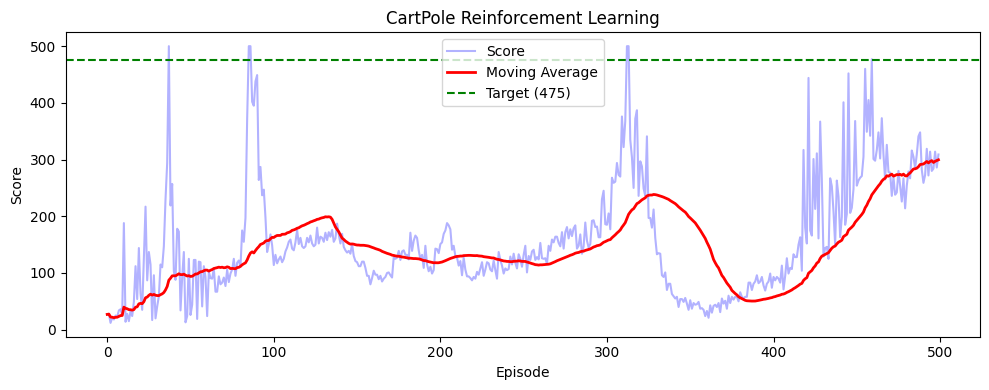

In [22]:
import matplotlib
matplotlib.rcdefaults()  # 폰트 설정 완전 초기화

import matplotlib.pyplot as plt

window = 50
moving_avg = [np.mean(scores[max(0,i-window):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10,4))
plt.plot(scores, alpha=0.3, color='blue', label='Score')
plt.plot(moving_avg, color='red', linewidth=2, label='Moving Average')
plt.axhline(y=475, color='green', linestyle='--', label='Target (475)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('CartPole Reinforcement Learning')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_6245/4058853071.py:15: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6245/4058853071.py:15: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6245/4058853071.py:15: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6245/4058853071.py:15: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6245/4058853071.py:15: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6245/4058853071.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6245/4058853071.py:15: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

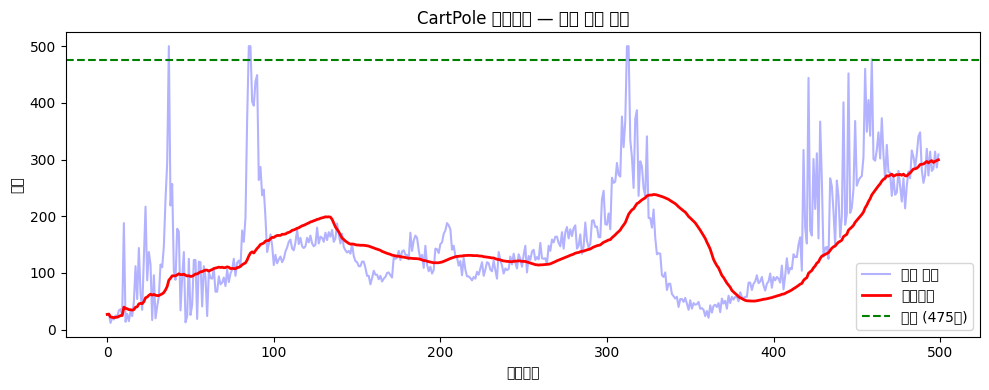

In [23]:
import matplotlib.pyplot as plt

# 50회 이동평균
window = 50
moving_avg = [np.mean(scores[max(0,i-window):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10,4))
plt.plot(scores, alpha=0.3, color='blue', label='실제 점수')
plt.plot(moving_avg, color='red', linewidth=2, label='이동평균')
plt.axhline(y=475, color='green', linestyle='--', label='목표 (475점)')
plt.xlabel('에피소드')
plt.ylabel('점수')
plt.title('CartPole 강화학습 — 란의 성장 곡선')
plt.legend()
plt.tight_layout()
plt.show()

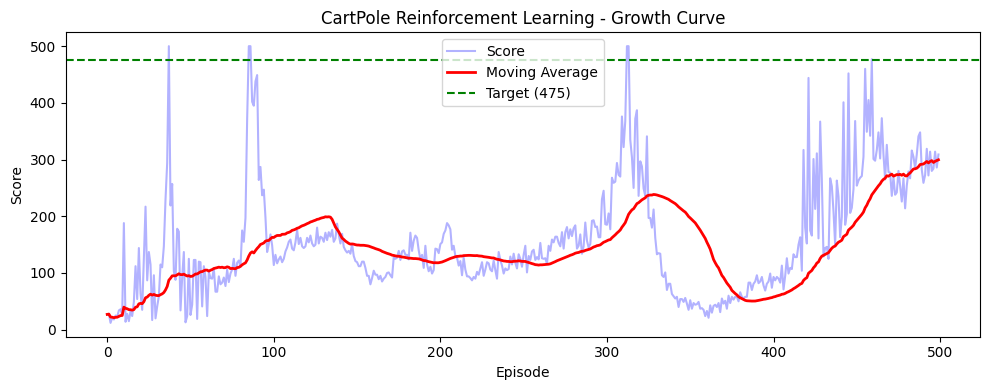

In [24]:
import matplotlib.pyplot as plt

window = 50
moving_avg = [np.mean(scores[max(0,i-window):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10,4))
plt.plot(scores, alpha=0.3, color='blue', label='Score')
plt.plot(moving_avg, color='red', linewidth=2, label='Moving Average')
plt.axhline(y=475, color='green', linestyle='--', label='Target (475)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('CartPole Reinforcement Learning - Growth Curve')
plt.legend()
plt.tight_layout()
plt.show()

이미지 저장 완료
코랩 상단 메뉴 → 파일 → 드라이브에 사본 저장 해줘요


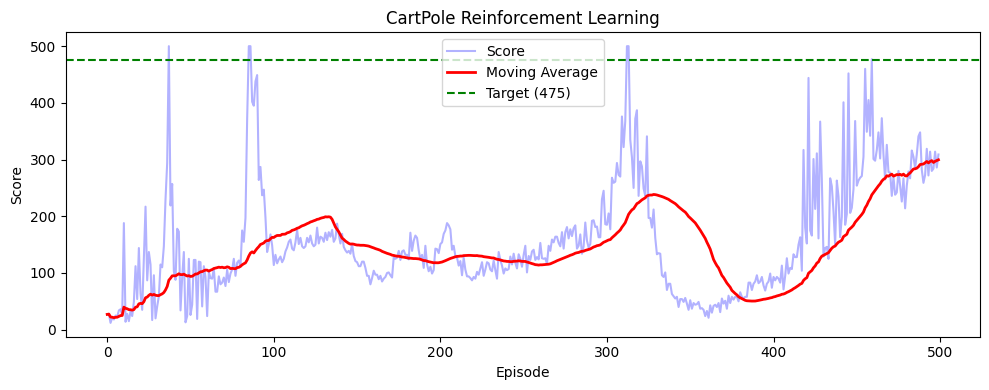

In [25]:
# 그래프 이미지 저장
import matplotlib.pyplot as plt

window = 50
moving_avg = [np.mean(scores[max(0,i-window):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10,4))
plt.plot(scores, alpha=0.3, color='blue', label='Score')
plt.plot(moving_avg, color='red', linewidth=2, label='Moving Average')
plt.axhline(y=475, color='green', linestyle='--', label='Target (475)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('CartPole Reinforcement Learning')
plt.legend()
plt.tight_layout()
plt.savefig('cartpole_result.png', dpi=150, bbox_inches='tight')
print("이미지 저장 완료")

# 노트북 저장 확인
print("코랩 상단 메뉴 → 파일 → 드라이브에 사본 저장 해줘요")

저장 완료


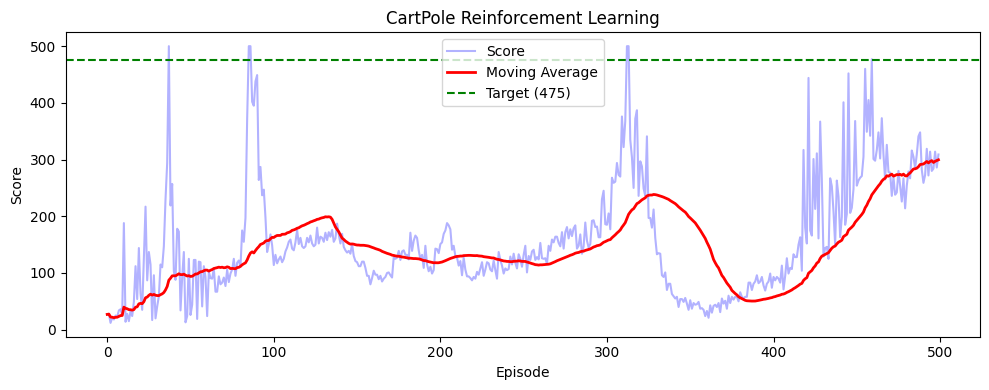

In [26]:
import matplotlib.pyplot as plt
import numpy as np

window = 50
moving_avg = [np.mean(scores[max(0,i-window):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10,4))
plt.plot(scores, alpha=0.3, color='blue', label='Score')
plt.plot(moving_avg, color='red', linewidth=2, label='Moving Average')
plt.axhline(y=475, color='green', linestyle='--', label='Target (475)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('CartPole Reinforcement Learning')
plt.legend()
plt.tight_layout()
plt.savefig('cartpole_result.png', dpi=150, bbox_inches='tight')
print("저장 완료")